### IMPORTACIONES Y CONFIGURACIONES

In [8]:
import os
import json
import zipfile
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns # Uso principal para heatmap y gráficas

# Bibliotecas de Deep Learning y Wrappers
import tensorflow as tf
from scikeras.wrappers import KerasClassifier

# Bibliotecas de Balanceo y Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Bibliotecas de Scikit-learn 
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import FitFailedWarning, ConvergenceWarning
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures, FunctionTransformer

# Métricas (Incluye las métricas para el reporte y las funciones para las curvas)
from sklearn.metrics import (
    f1_score, accuracy_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, matthews_corrcoef,
    roc_curve, auc, precision_recall_curve
)

# Modelos 
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Utilidades Varias
import ast
import joblib


warnings.filterwarnings("ignore")
SEED = 42
# Reducción de la Validación Cruzada de 5 a 3.
# Justificación: Reduce el tiempo de entrenamiento en un 40% para cada
# combinación de hiperparámetros en el Grid Search (GridSearchCV).
CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

# Scoring múltiple: refit por F1
SCORINGS = {
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "accuracy": "accuracy",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision"
}
REFIT = "f1" # utilizamos f1-score porque en la competición se evalúa con esta métrica


### Importar datasets del notebook de la parte 1, "preprocess.ipynb" (guardados en el zip processed_dataset.csv.zip):


In [9]:
ZIP_PATH = "processed_dataset.csv.zip"

# Lógica de carga
def _read_csv_from_zip(zf, name):
    with zf.open(name) as f:
        return pd.read_csv(f)

# Diccionario para almacenar todos los conjuntos de datos de TRAIN, VALIDACIÓN y KAGGLE
DATASETS = {}

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    meta = json.loads(z.read("meta.json").decode("utf-8"))
    label_classes = meta["label_encoder_classes"]
    
    # Definir los nombres de archivo a cargar
    conjuntos_a_cargar = {
        # Llave del diccionario : {Nombre usado para la variable, Nombre de archivo train, Nombre de archivo valid, Nombre de archivo kaggle}
        "STD": {"name": "rfecv_std", "train": "train_rfecv_std.csv", "valid": "valid_rfecv_std.csv", "kaggle": "kaggle_rfecv_std.csv"},
        "MINMAX": {"name": "rfecv_minmax", "train": "train_rfecv_minmax.csv", "valid": "valid_rfecv_minmax.csv", "kaggle": "kaggle_rfecv_minmax.csv"},
        "LR_UNSCALED": {"name": "rfecv_lr_unscaled", "train": "train_rfecv_lr.csv", "valid": "valid_rfecv_lr.csv", "kaggle": "kaggle_rfecv_lr.csv"},
    }

    # Bucle para cargar, separar y almacenar los 3 sets en DATASETS
    for key, files in conjuntos_a_cargar.items():
        
        # Carga
        train_df = _read_csv_from_zip(z, files["train"])
        valid_df = _read_csv_from_zip(z, files["valid"])
        kaggle_df = _read_csv_from_zip(z, files["kaggle"])
        
        # Separar X, y, e ID
        y_train = train_df["salario_encoded"].astype(int).values
        X_train = train_df.drop(columns=[c for c in ["salario_encoded","salario"] if c in train_df.columns])
        
        y_valid = valid_df["salario_encoded"].astype(int).values
        X_valid = valid_df.drop(columns=[c for c in ["salario_encoded","salario"] if c in valid_df.columns])
        
        ids_kaggle = kaggle_df["ID"] if "ID" in kaggle_df.columns else None
        X_kaggle = kaggle_df.drop(columns=["ID"]) if "ID" in kaggle_df.columns else kaggle_df.copy()

        # Almacenamiento de las variables X, y, y el ID
        DATASETS[key] = {
            "name": files["name"],
            "X_train": X_train, "y_train": y_train,
            "X_valid": X_valid, "y_valid": y_valid,
            "X_kaggle": X_kaggle, "ids_kaggle": ids_kaggle
        }

# Asignar un conjunto por defecto (STD) a las variables globales (X_train, etc.)
# Esto es solo por si alguna celda futura usa X_train sin pasar por el diccionario.
X_train = DATASETS["STD"]["X_train"]
y_train = DATASETS["STD"]["y_train"]
X_valid = DATASETS["STD"]["X_valid"]
y_valid = DATASETS["STD"]["y_valid"]
X_kaggle = DATASETS["STD"]["X_kaggle"]
ids_kaggle = DATASETS["STD"]["ids_kaggle"]

num_cols = [c for c in X_train.columns if c.startswith("num__")]

print(f"Datasets cargados correctamente: STD, MINMAX, LR_UNSCALED. (Total: {len(DATASETS)} sets)")
print(f"Ejemplo (STD) | X_train={X_train.shape}, X_valid={X_valid.shape}, X_kaggle={X_kaggle.shape}")
print(f"Numéricas a escalar (en crudo): {len(num_cols)}")


Datasets cargados correctamente: STD, MINMAX, LR_UNSCALED. (Total: 3 sets)
Ejemplo (STD) | X_train=(34064, 83), X_valid=(5600, 83), X_kaggle=(4563, 83)
Numéricas a escalar (en crudo): 3


`make_prep` es, básicamente, un preprocesador que solo se activa cuando queremos añadir no linealidad. Si le pasamos un grado, coge las columnas numéricas, genera términos polinomiales (potencias e interacciones) y después las vuelve a escalar para que el modelo no se desestabilice por diferencias de magnitud. Todo eso va dentro de un `ColumnTransformer` que deja pasar el resto de variables tal cual (las categóricas ya vienen one-hot). Si no le damos grado, no toca nada y devuelve `"passthrough"`. La razón de hacerlo así es que va dentro del pipeline de validación cruzada: se ajusta únicamente con los folds de entrenamiento, evita fuga de información y nos permite probar el mejor grado en el grid. En nuestra práctica lo usamos solo para el modelo “polinomial”; los demás no lo necesitan porque el escalado base ya se hizo en el preprocess.


In [10]:
# Escalado (preproceso) + evaluación

def make_prep(poly_degree=None):
    if poly_degree is None or not num_cols:
        return "passthrough"
    num_pipe = Pipeline([
        ("poly", PolynomialFeatures(degree=poly_degree, include_bias=False)),
        ("scaler", StandardScaler()),  # reescala numéricas + sus términos
    ])
    return ColumnTransformer([("num", num_pipe, num_cols)], remainder="passthrough")



def summarize_valid(estimator, Xva, yva, label_classes):
    y_pred = estimator.predict(Xva)

    y_score = None
    if hasattr(estimator, "predict_proba"):
        y_score = estimator.predict_proba(Xva)[:, 1]
    elif hasattr(estimator, "decision_function"):
        y_score = estimator.decision_function(Xva)

    out = {
        "valid_f1": f1_score(yva, y_pred),
        "valid_precision": precision_score(yva, y_pred),
        "valid_recall": recall_score(yva, y_pred),
        "valid_accuracy": accuracy_score(yva, y_pred),
        "valid_mcc": matthews_corrcoef(yva, y_pred),
        "valid_roc_auc": (roc_auc_score(yva, y_score) if y_score is not None else np.nan),
        "valid_pr_auc": (average_precision_score(yva, y_score) if y_score is not None else np.nan),
        "report": classification_report(yva, y_pred, target_names=label_classes, digits=4),
        "confusion_matrix": confusion_matrix(yva, y_pred)
    }
    return out

### A continuación, implementamos funciones que nos permitan graficar distintos resultados: curvas ROC, matrices de confusión y gráficos de barras para comparar métricas.

In [11]:
def plot_feature_importance_final(estimator, feature_names, n_top=10, model_name="Modelo"):
    """
    Calcula y grafica la importancia de las N features más relevantes para modelos 
    lineales (magnitud de coeficientes) y basados en árboles.
    """
    
    # Intentar acceder al clasificador dentro del pipeline
    classifier = estimator.named_steps.get('clf')
    
    # Modelos Lineales (LogisticRegression, SGDClassifier)
    if hasattr(classifier, 'coef_'):
        # Coeficientes para clasificación binaria (solo 1 fila)
        coef = classifier.coef_[0] if classifier.coef_.ndim > 1 else classifier.coef_
        importance = np.abs(coef)
        title = f"Magnitud de Coeficientes (Top {n_top}) - {model_name}"
        
    # Modelos Basados en Árboles/Ensembles (DecisionTree, RandomForest) -
    elif hasattr(classifier, 'feature_importances_'):
        importance = classifier.feature_importances_
        title = f"Importancia de Características (Top {n_top}) - {model_name}"
        
    else:
        print(f"No se puede calcular la importancia para {model_name}.")
        return

    # Si la transformación Polinomial se ejecutó, el número de features puede variar.
    # Debemos manejar la alineación de nombres.
    
    # Si el número de importancias es mayor que el número de features iniciales,
    # asumimos que hubo transformación (ej., PolinomialFeatures) y simplificamos los nombres.
    if len(importance) != len(feature_names):
        print("Advertencia: Se detectó transformación Polinomial o similar. Usando nombres genéricos.")
        # Generar nombres de features genéricos para el plot
        feature_names_plot = [f'Feature_{i}' for i in range(len(importance))]
    else:
        feature_names_plot = feature_names


    # Crear Series para ordenar
    feature_importance_series = pd.Series(importance, index=feature_names_plot)
    
    # Obtener las N más importantes
    top_features = feature_importance_series.nlargest(n_top)
    
    # Graficar
    plt.figure(figsize=(10, 6))
    top_features.sort_values(ascending=True).plot(kind='barh', color='darkred')
    plt.title(title)
    plt.xlabel('Importancia / Magnitud')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

    
# Función Auxiliar para Obtener Scores 
def _get_model_scores(estimator, X_val):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_val)[:, 1]
    elif hasattr(estimator, "decision_function"):
        return estimator.decision_function(X_val)
    return None

# Función Principal que genera Fila de 3 Gráficas
def plot_model_summary(estimator, X_val, y_val, class_names, model_name):
    
    # Predecir etiquetas y obtener scores
    y_pred = estimator.predict(X_val)
    y_score = _get_model_scores(estimator, X_val)
    
    # Configurar la Figura (1 fila, 3 columnas)
    # El tamaño 18x5 es bueno para 3 gráficas en una fila.
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'Rendimiento del Modelo: {model_name}', fontsize=16)

    
    # Subgráfico 1: matriz de confusión
    
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(
        cm, ax=axes[0], annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names, linewidths=.5, cbar=False
    )
    axes[0].set_title('Matriz de Confusión')
    axes[0].set_ylabel('Etiqueta Verdadera')
    axes[0].set_xlabel('Etiqueta Predicha')

    
    # Subgráfico 2: curva ROC
    
    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_val, y_score)
        roc_auc = auc(fpr, tpr)
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, 
                     label=f'AUC = {roc_auc:.4f}')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        axes[1].set_title('Curva ROC')
        axes[1].set_xlabel('FPR')
        axes[1].set_ylabel('TPR')
        axes[1].legend(loc="lower right")
    else:
        axes[1].set_title('Curva ROC (No disponible)')


    # Subgráfico 3: curva PRECISION-RECALL (PR)

    if y_score is not None:
        precision, recall, _ = precision_recall_curve(y_val, y_score)
        avg_precision = average_precision_score(y_val, y_score)
        
        # Baseline
        baseline = len(y_val[y_val==1]) / len(y_val)
        axes[2].plot([0, 1], [baseline, baseline], linestyle='--', color='gray', label=f'Línea base ({baseline:.2f})')
        
        axes[2].plot(recall, precision, color='purple', lw=2, 
                     label=f'PR-AUC = {avg_precision:.4f}')
        axes[2].set_title('Curva Precision-Recall')
        axes[2].set_xlabel('Recall')
        axes[2].set_ylabel('Precision')
        axes[2].legend(loc="lower left")
    else:
        axes[2].set_title('Curva PR (No disponible)')
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el layout para que el título principal quepa
    plt.show()

def plot_confusion_matrix(cm, class_names, title='Matriz de Confusión'):
    """
    Grafica la matriz de confusión como un mapa de calor (heatmap).
    
    Args:
        cm (np.ndarray): La matriz de confusión (e.g., de sklearn.metrics.confusion_matrix).
        class_names (list): Nombres de las clases (e.g., ['<=50K', '>50K']).
        title (str): Título de la gráfica.
    """
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, 
        annot=True,        # Muestra los valores de cada celda
        fmt='d',           # Formato decimal 
        cmap='Blues',      # Esquema de color azulado
        xticklabels=class_names,
        yticklabels=class_names,
        linewidths=.5,     # Líneas separadoras
        cbar=False         # No muestra la barra de color
    )
    plt.title(title)
    plt.ylabel('Etiqueta Verdadera')
    plt.xlabel('Etiqueta Predicha')
    plt.show() 

### Creación de modelos supervisados con Grid Search y Cross Validation:

### Optimizaciones aplicadas (Grid Search)

> Hemos aplicado optimizaciones en la configuración de los modelos y la validación cruzada para reducir el tiempo de ejecución del Grid Search, que se estaba volviendo excesivo debido al gran volumen de datos (34,064 muestras con SMOTE):
>
>        - Reducción de la Validación Cruzada: hemos decidido reducir n_splits de 5 a 3 en la variable global CV.El Grid Search entrena cada combinación de hiperparámetros CV veces. Al reducir de 5 a 3, se reduce el número total de entrenamientos para todos los modelos, lo que acelera notablemente el proceso sin comprometer gravemente la calidad de la validación.


### Red de neuronas con Keras y TensorFlow:

In [12]:
# MLP fully-connected con Dropout 
def build_fc_dropout_model(meta, hidden_layer_sizes=(64, 64), activation="relu",
                           alpha=3e-3, dropout_rate=0.2):
    # SciKeras pasa 'meta' con n_features_in_
    input_dim = meta["n_features_in_"]
    if isinstance(hidden_layer_sizes, int):
        hidden_layer_sizes = (hidden_layer_sizes,)

    inputs = tf.keras.Input(shape=(input_dim,))
    x = inputs
    for units in hidden_layer_sizes:
        x = tf.keras.layers.Dense(
            units,
            activation=activation,
            kernel_regularizer=tf.keras.regularizers.l2(alpha)
        )(x)
        x = tf.keras.layers.Dropout(dropout_rate)(x)

    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model


### Resto de modelos supervisados:

In [13]:
models = {}

# Modelos que usan Standard Scaler:
# Estos pipelines asumen que hemos cargado train_rfecv_std.csv

# Lineal (SVM lineal con SGD) + Standard
pipe_linear = ImbPipeline([
    ("prep", make_prep()),  # 'passthrough' si no hay poly
    ("smote", SMOTE(random_state=SEED)),
    ("clf", SGDClassifier(loss="hinge", max_iter=2000, random_state=SEED, class_weight=None))
])
grid_linear = {
    "smote": ["passthrough", SMOTE(random_state=SEED, k_neighbors=3)],
    "clf__alpha": [1e-3, 3e-3, 1e-2],
    "clf__penalty": ["l2"],
    "clf__class_weight": [None, {0: 1.25, 1: 1.0}, {0: 1.5, 1: 1.0}],
}
models["linear_svm_std"] = (pipe_linear, grid_linear)

# Logística + Standard Scaler
pipe_log = ImbPipeline([
    ("prep", make_prep()),
    ("smote", SMOTE(random_state=SEED)),
    ("clf", LogisticRegression(max_iter=6000, solver="liblinear", class_weight=None))
])
grid_log = {
    "smote": ["passthrough", SMOTE(random_state=SEED, k_neighbors=3)],
    "clf__C": [0.25, 0.5, 1.0],
    "clf__penalty": ["l1", "l2"],
    "clf__class_weight": [None, {0: 1.25, 1: 1.0}, {0: 1.5, 1: 1.0}],
}
models["logistic_std"] = (pipe_log, grid_log)

# SVM RBF + Standard
pipe_svm = ImbPipeline([
    ("prep", make_prep()),
    ("smote", SMOTE(random_state=SEED)),
    ("clf", SVC(kernel="rbf", probability=True, class_weight=None, random_state=SEED))
])
grid_svm = {
    "smote": ["passthrough", SMOTE(random_state=SEED, k_neighbors=3)],
    "clf__C": [1, 3, 5],
    "clf__gamma": ["scale"],
    "clf__class_weight": [None, {0: 1.25, 1: 1.0}, {0: 1.5, 1: 1.0}],
}
models["svm_rbf_std"] = (pipe_svm, grid_svm)

# Polinomial (Logística + poly solo en numéricas) + Standard Scaler
pipe_poly = ImbPipeline([
    ("prep", make_prep(poly_degree=2)),
    ("smote", SMOTE(random_state=SEED)),
    ("clf", LogisticRegression(max_iter=6000, solver="liblinear", class_weight=None))
])
grid_poly = {
    "smote": ["passthrough", SMOTE(random_state=SEED, k_neighbors=3)],
    "prep__num__poly__degree": [2],
    "clf__C": [0.5, 1, 2],
    "clf__penalty": ["l1", "l2"],
    "clf__class_weight": [None, {0: 1.25, 1: 1.0}, {0: 1.5, 1: 1.0}],
}
models["polynomial_logreg_std"] = (pipe_poly, grid_poly)


# Modelos que usan MinMax Scaler:
# Estos pipelines asumen que hemos cargado train_rfecv_minmax.csv

# kNN + MinMax
pipe_knn = ImbPipeline([
    ("prep", make_prep()),
    ("smote", SMOTE(random_state=SEED)),
    ("clf", KNeighborsClassifier())
])
grid_knn = {
    "smote": ["passthrough", SMOTE(random_state=SEED, k_neighbors=3)],
    "clf__n_neighbors": [15, 21, 31],
    "clf__weights": ["distance"],
    "clf__p": [2],
}
models["knn_minmax"] = (pipe_knn, grid_knn)

# MLP sklearn + MINMAX — sin Dropout (aunque alpha es un término regulador que puede hacer de "drop out")
pipe_mlp_sklearn = ImbPipeline([
    ("prep", make_prep()),
    ("smote", SMOTE(random_state=SEED)),
    ("clf", MLPClassifier(max_iter=1000, early_stopping=True, random_state=SEED))
])
grid_mlp_sklearn = {
    "clf__hidden_layer_sizes": [(64, 64), (100,), (64, 64, 32)],
    "clf__activation": ["relu"],
    "clf__alpha": [1e-3, 1e-2],
}
models["mlp_minmax"] = (pipe_mlp_sklearn, grid_mlp_sklearn)

# MLP Keras + MinMax — con Dropout (SciKeras, sin traceback)
pipe_mlp_keras = ImbPipeline([
    ("prep", make_prep()),
    ("smote", SMOTE(random_state=SEED)),
    ("clf", KerasClassifier(
        model=build_fc_dropout_model,
        # compile gestionado por SciKeras:
        loss="binary_crossentropy",
        optimizer="adam",
        metrics=None,  # evitar registrar 'loss' como métrica
        # entrenamiento:
        epochs=60,
        batch_size=512,
        verbose=0,
        validation_split=0.10,
        callbacks=[tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=6, restore_best_weights=True
        )],
        random_state=SEED
    ))
])
grid_mlp_keras = {
    "smote": ["passthrough"],  # evita combinaciones muy costosas
    "clf__model__hidden_layer_sizes": [(64, 64), (128, 64)],
    "clf__model__alpha": [3e-3, 1e-2],
    "clf__model__dropout_rate": [0.2, 0.3],
    "clf__class_weight": [None, {0: 1.25, 1: 1.0}],
}
models["mlp_minmax_keras"] = (pipe_mlp_keras, grid_mlp_keras)


# Modelos que no usan escalado:
# Estos pipelines asumen que hemos cargado train_rfecv_lr.csv 

# Árboles de decisión (sin escalado) 
pipe_tree = ImbPipeline([
    ("prep", make_prep()),
    ("smote", SMOTE(random_state=SEED)),
    ("clf", DecisionTreeClassifier(random_state=SEED, class_weight=None))
])
grid_tree = {
    "smote": ["passthrough", SMOTE(random_state=SEED, k_neighbors=3)],
    "clf__max_depth": [8, 12, 16],
    "clf__min_samples_leaf": [5, 10, 20],
    "clf__min_samples_split": [10, 20],
    "clf__class_weight": [None, {0: 1.25, 1: 1.0}, {0: 1.5, 1: 1.0}],
}
models["decision_tree_unscaled"] = (pipe_tree, grid_tree)

# Random Forest (sin escalado)
pipe_rf = ImbPipeline([
    ("prep", make_prep()), # passthrough
    ("smote", SMOTE(random_state=SEED)),
    ("clf", RandomForestClassifier(random_state=SEED, class_weight=None))
])
grid_rf = {
    "smote": ["passthrough", SMOTE(random_state=SEED, k_neighbors=3)],
    "clf__n_estimators": [100, 200], # número de árboles
    "clf__max_depth": [10, 16],
    "clf__min_samples_leaf": [5, 10],
    "clf__class_weight": [None, {0: 1.25, 1: 1.0}],
}
models["random_forest_unscaled"] = (pipe_rf, grid_rf)

### GRID SEARCH Y EVALUACIÓN DE MODELOS (multi-métrica) 


La implementación de SciKeras en nuestro proyecto es una decisión esencial que cumple los requisitos del modelo de Red Neuronal. SciKeras actúa como un "puente", permitiéndonos utilizar redes neuronales de Keras/TensorFlow como si fuesen estimadores nativos de scikit-learn. Esto nos ofrece dos ventajas fundamentales: por un lado, facilita el uso de la misma API (.fit, .predict_proba) para todos los modelos, manteniendo la uniformidad. Además, permite encapsular la red dentro de un ImbPipeline junto con SMOTE y, ejecutar el ajuste de hiperparámetros (GridSearchCV) de manera eficiente. Esto nos permite sintonizar parámetros complejos como las tasas de dropout (clf__model__dropout) y las arquitecturas de capas (clf__model__hidden_layer_sizes) bajo el esquema de la validación cruzada de scikit-learn.


 LINEAR_SVM_STD | dataset=rfecv_std (Train Shape: (34064, 83))


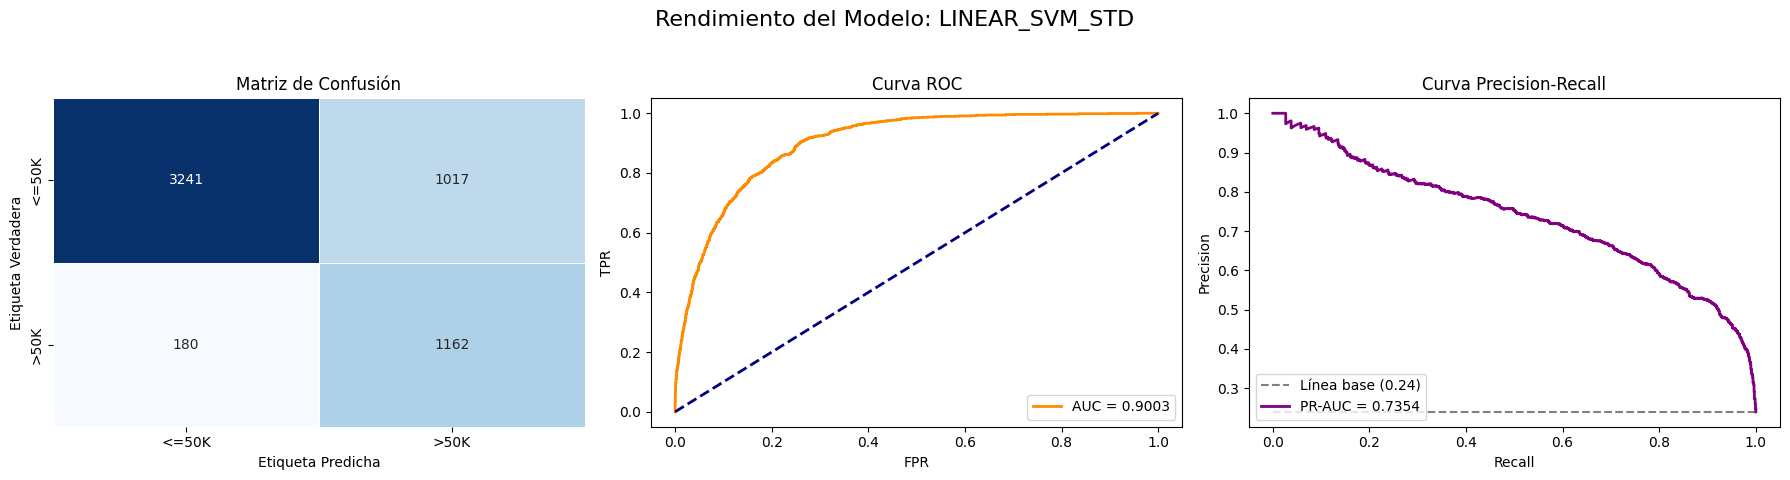


 LOGISTIC_STD | dataset=rfecv_std (Train Shape: (34064, 83))


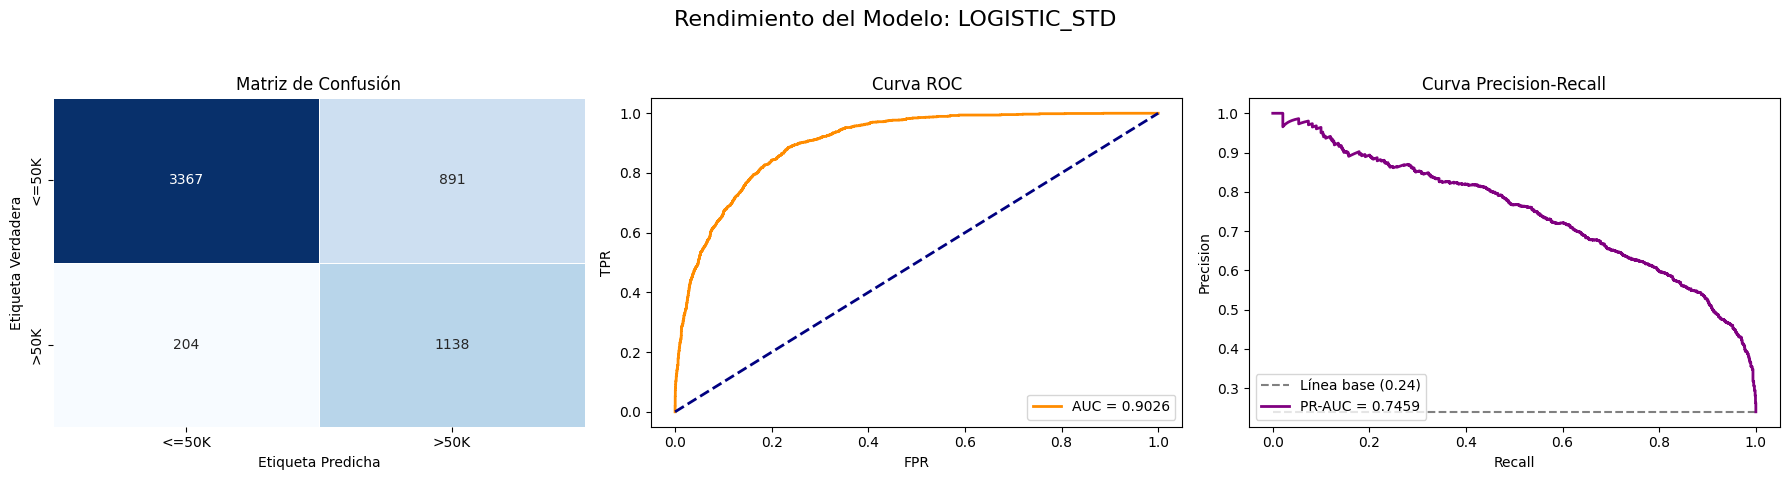


 SVM_RBF_STD | dataset=rfecv_std (Train Shape: (34064, 83))


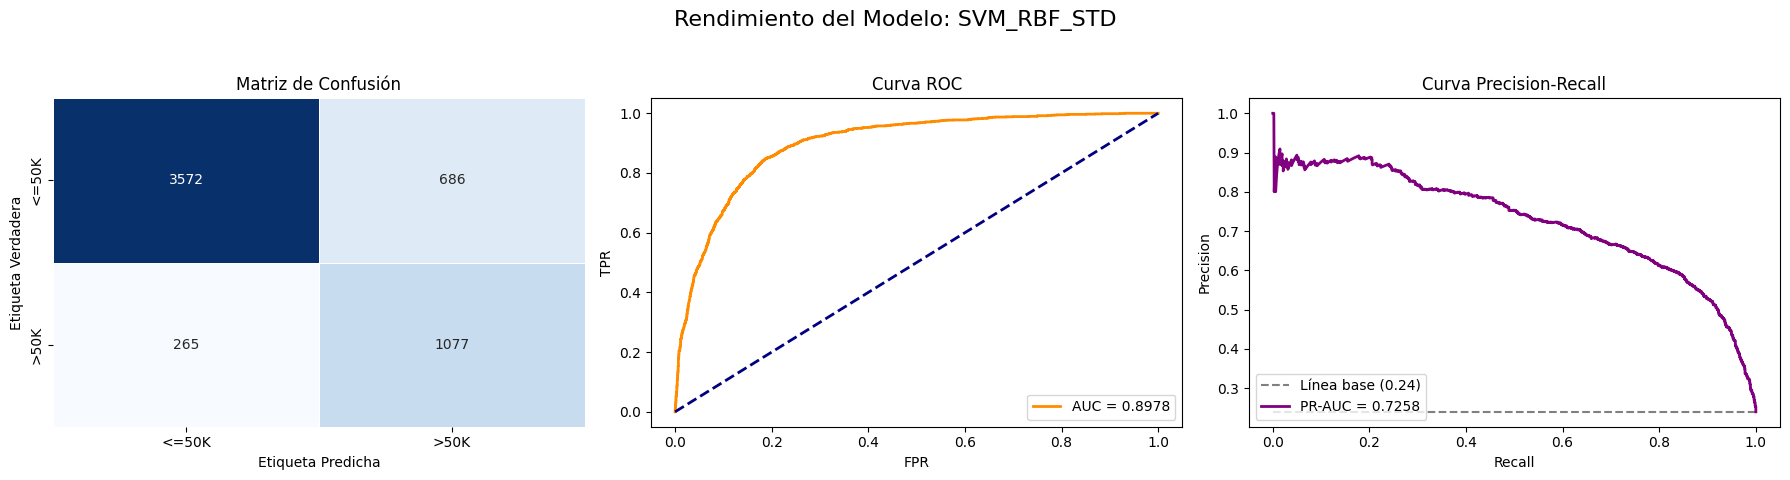


 POLYNOMIAL_LOGREG_STD | dataset=rfecv_std (Train Shape: (34064, 83))


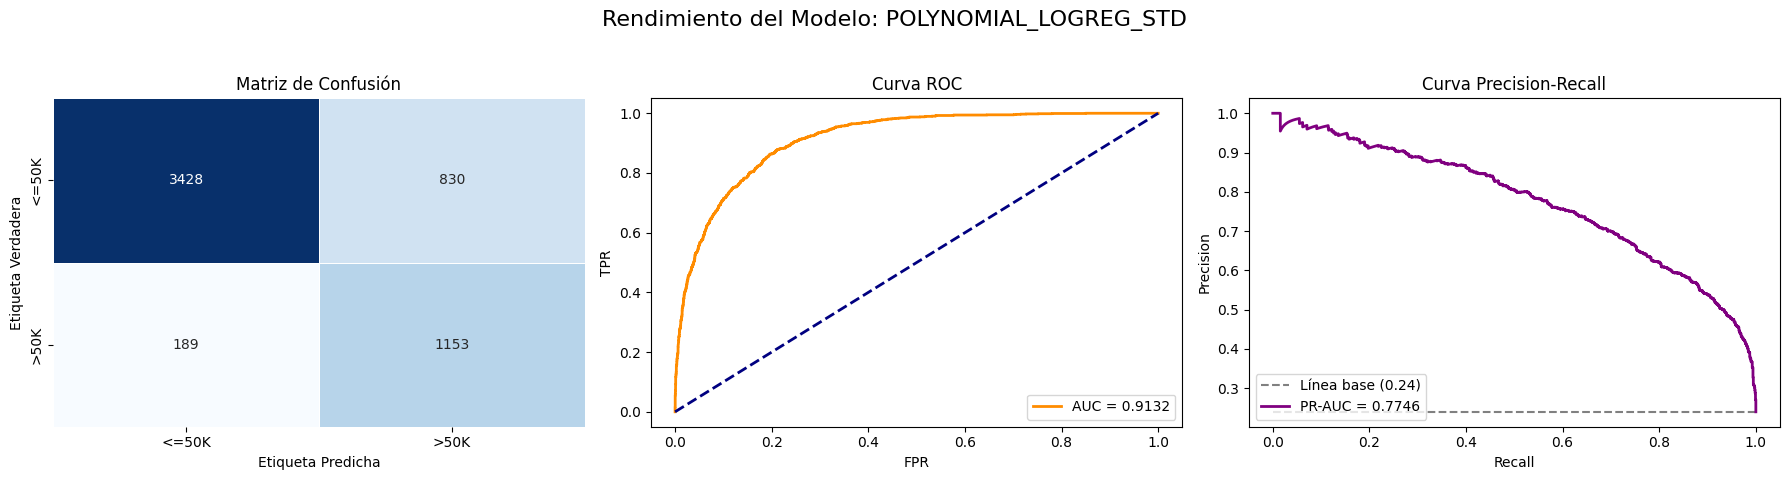


 KNN_MINMAX | dataset=rfecv_minmax (Train Shape: (34064, 83))


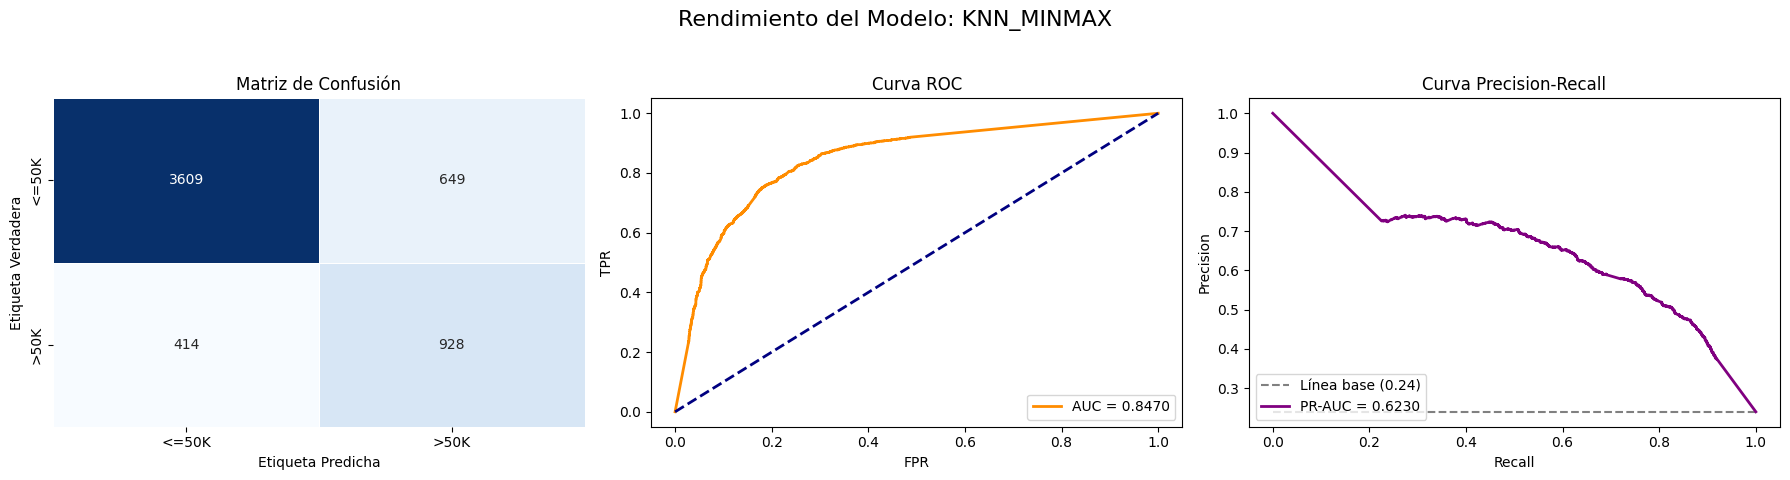


 MLP_MINMAX | dataset=rfecv_minmax (Train Shape: (34064, 83))


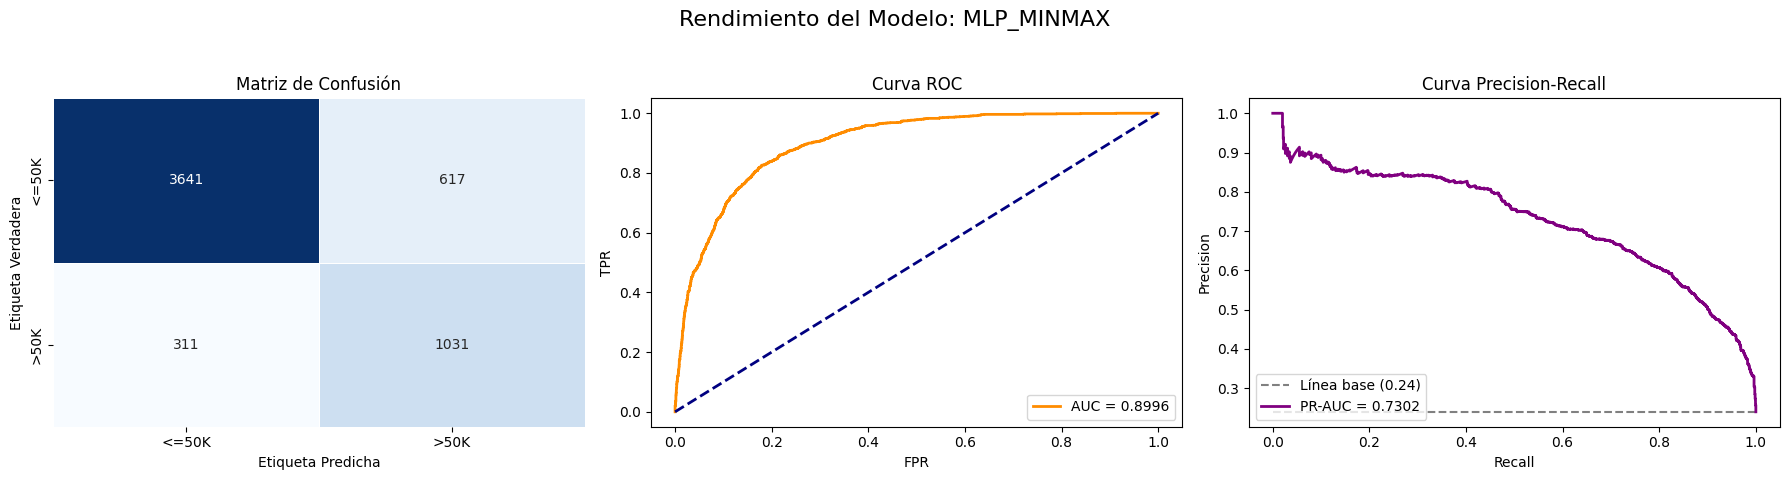


 MLP_MINMAX_KERAS | dataset=rfecv_minmax (Train Shape: (34064, 83))
[MLP_MINMAX_KERAS] Se ha producido un error al ajustar el modelo Keras (se omite silenciosamente del experimento).

 DECISION_TREE_UNSCALED | dataset=rfecv_lr_unscaled (Train Shape: (22398, 83))


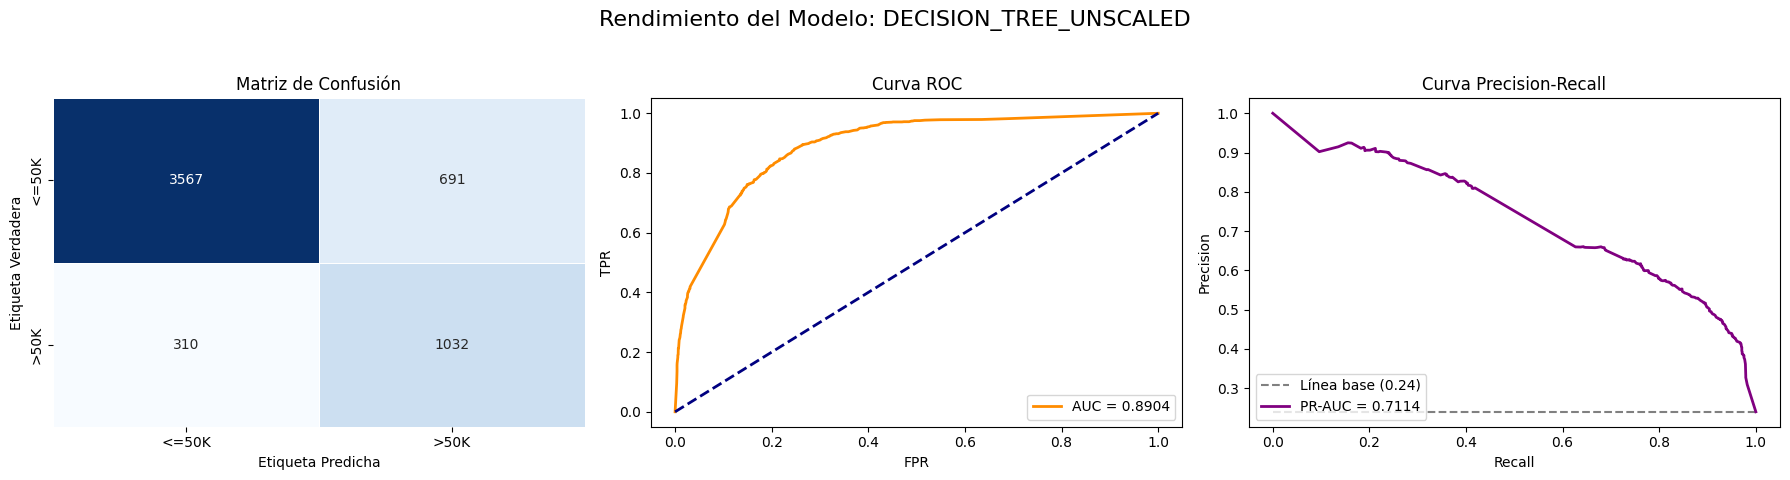


 RANDOM_FOREST_UNSCALED | dataset=rfecv_lr_unscaled (Train Shape: (22398, 83))


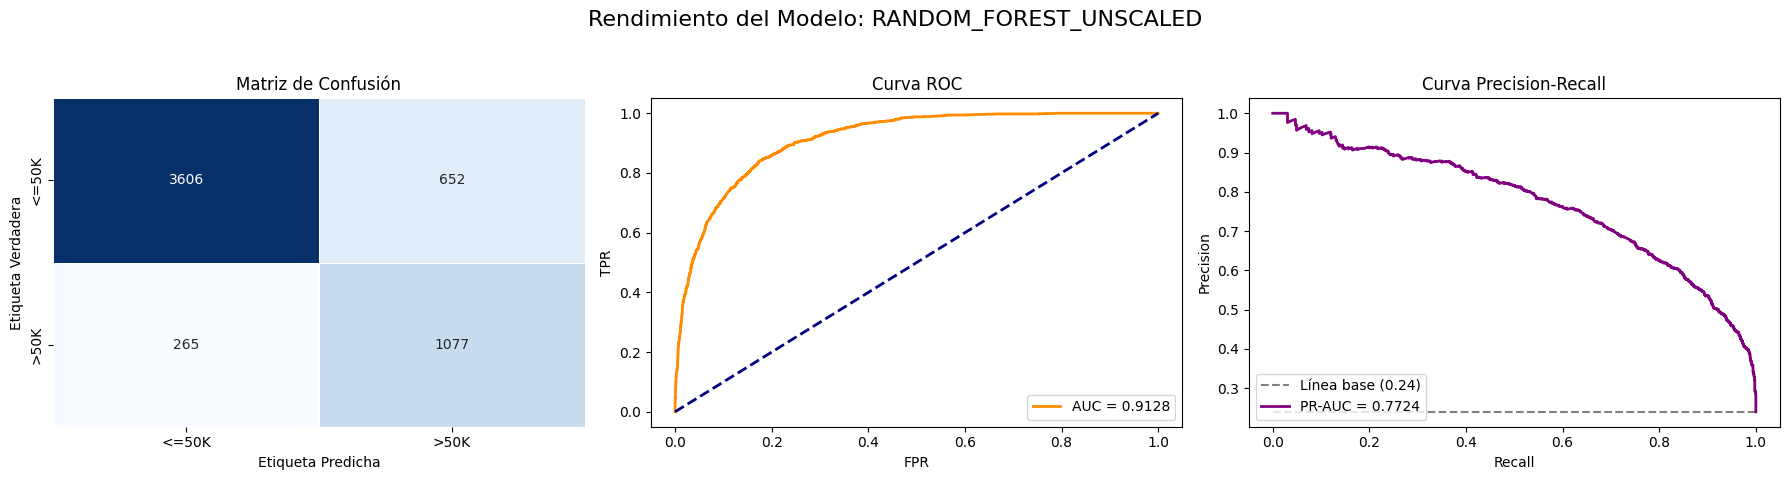

,model,dataset,best_params,cv_precision,cv_f1,cv_recall,cv_accuracy,cv_roc_auc,cv_pr_auc,valid_precision,valid_f1,valid_recall,valid_accuracy,valid_mcc,valid_roc_auc,valid_pr_auc
0,random_forest_unscaled,rfecv_lr_unscaled,"{'clf__class_weight': {0: 1.25, 1: 1.0}, 'clf_...",0.620154,0.683121,0.760717,0.830878,0.900359,0.741754,0.622903,0.701400,0.802534,0.836250,0.600052,0.912797,0.772407
1,svm_rbf_std,rfecv_std,"{'clf__C': 5, 'clf__class_weight': None, 'clf_...",0.843419,0.875634,0.910463,0.870685,0.947140,0.946824,0.610891,0.693720,0.802534,0.830179,0.589526,0.897828,0.725819
2,polynomial_logreg_std,rfecv_std,"{'clf__C': 1, 'clf__class_weight': None, 'clf_...",0.819095,0.844240,0.871008,0.839302,0.916604,0.905605,0.581442,0.693534,0.859165,0.818036,0.592881,0.913222,0.774581
3,mlp_minmax,rfecv_minmax,"{'clf__activation': 'relu', 'clf__alpha': 0.00...",0.849725,0.868370,0.888092,0.865430,0.942476,0.937586,0.625607,0.689632,0.768256,0.834286,0.583883,0.899571,0.730183
4,logistic_std,rfecv_std,"{'clf__C': 1.0, 'clf__class_weight': None, 'cl...",0.807962,0.834907,0.863727,0.829204,0.908296,0.893296,0.560867,0.675171,0.847988,0.804464,0.567236,0.902588,0.745875
5,decision_tree_unscaled,rfecv_lr_unscaled,"{'clf__class_weight': None, 'clf__max_depth': ...",0.581828,0.657721,0.758674,0.810876,0.878246,0.694474,0.598955,0.673409,0.769001,0.821250,0.561146,0.890416,0.711431
6,linear_svm_std,rfecv_std,"{'clf__alpha': 0.001, 'clf__class_weight': Non...",0.788548,0.832398,0.881517,0.822511,0.903400,0.887964,0.533272,0.660040,0.865872,0.786250,0.548985,0.900272,0.735368
7,knn_minmax,rfecv_minmax,"{'clf__n_neighbors': 15, 'clf__p': 2, 'clf__we...",0.847926,0.852041,0.856212,0.851309,0.913093,0.886277,0.588459,0.635834,0.691505,0.810179,0.511619,0.847033,0.622968


In [15]:
# Silenciar avisos de fits fallidos para que no salga ningún traceback ni warnings ruidosos
from sklearn.exceptions import FitFailedWarning, ConvergenceWarning
import warnings

warnings.filterwarnings("ignore", category=FitFailedWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# REFIT = "f1"
DATASET_MODEL_MAP = {
    "logistic_std": "STD",
    "linear_svm_std": "STD",
    "svm_rbf_std": "STD",
    "polynomial_logreg_std": "STD",
    "knn_minmax": "MINMAX",
    "mlp_minmax": "MINMAX",
    "mlp_minmax_keras": "MINMAX",
    "decision_tree_unscaled": "LR_UNSCALED",
    "random_forest_unscaled": "LR_UNSCALED",
}

all_rows = []
best_estimators = {}

for key, (pipe, grid) in models.items():

    dataset_key = DATASET_MODEL_MAP.get(key, "STD")
    ds = DATASETS[dataset_key]

    X_train_ds, y_train_ds = ds["X_train"], ds["y_train"]
    X_valid_ds, y_valid_ds = ds["X_valid"], ds["y_valid"]
    dataset_name = ds["name"]

    print(f"\n {key.upper()} | dataset={dataset_name} (Train Shape: {X_train_ds.shape})")

    # Detectar si el último step es Keras
    is_keras = isinstance(pipe.named_steps.get("clf"), KerasClassifier)

    # Para Keras: n_jobs=1 y error_score numérico
    njobs = 1 if is_keras else -1
    errscore = np.nan if is_keras else "raise"

    if is_keras:
        pipe = pipe.set_params(
            clf__loss="binary_crossentropy",
            clf__optimizer="adam",
            clf__metrics=None,    # importante: no meter aquí "loss"
        )

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=grid,
        scoring=SCORINGS,
        refit=REFIT,
        cv=CV,
        n_jobs=njobs,
        verbose=0,
        return_train_score=False,
        error_score=errscore,
    )

    # evitar tracebacks cuando KERAS revienta todas las combinaciones
    try:
        gs.fit(X_train_ds, y_train_ds)
    except Exception as e:
        if is_keras:
            print(
                f"[{key.upper()}] Se ha producido un error al ajustar el modelo Keras "
                f"(se omite silenciosamente del experimento)."
            )
            # Nada de traceback, simplemente saltamos a siguiente modelo
            continue
        else:
            # Para modelos normales, si hay error de verdad sí lo queremos ver
            raise

    # Si (solo en Keras) todas las combinaciones devolvieron NaN, lo omitimos limpio
    if is_keras:
        f1_scores = gs.cv_results_["mean_test_f1"]
        if np.all(np.isnan(f1_scores)):
            print(f"[{key.upper()}] Todas las combinaciones devolvieron NaN; se omite este modelo.")
            continue

    best = gs.best_estimator_
    best_estimators[key] = best

    # Plots de resumen
    plot_model_summary(
        estimator=best,
        X_val=X_valid_ds,
        y_val=y_valid_ds,
        class_names=label_classes,
        model_name=key.upper(),
    )

    # Métricas CV
    idx = gs.best_index_
    row = {
        "model": key,
        "dataset": dataset_name,
        "best_params": gs.best_params_,
        "cv_precision": gs.cv_results_["mean_test_precision"][idx],
        "cv_f1":        gs.cv_results_["mean_test_f1"][idx],
        "cv_recall":    gs.cv_results_["mean_test_recall"][idx],
        "cv_accuracy":  gs.cv_results_["mean_test_accuracy"][idx],
        "cv_roc_auc":   gs.cv_results_["mean_test_roc_auc"][idx],
        "cv_pr_auc":    gs.cv_results_["mean_test_average_precision"][idx],
    }

    # Métricas en validación
    val_metrics = summarize_valid(best, X_valid_ds, y_valid_ds, label_classes)
    row.update({
        "valid_precision": val_metrics["valid_precision"],
        "valid_f1":        val_metrics["valid_f1"],
        "valid_recall":    val_metrics["valid_recall"],
        "valid_accuracy":  val_metrics["valid_accuracy"],
        "valid_mcc":       val_metrics["valid_mcc"],
        "valid_roc_auc":   val_metrics["valid_roc_auc"],
        "valid_pr_auc":    val_metrics["valid_pr_auc"],
    })
    all_rows.append(row)

results_df = (
    pd.DataFrame(all_rows)
    .sort_values("valid_f1", ascending=False)
    .reset_index(drop=True)
)
results_df


Para cada modelo construimos **pipeline** (escalado por modelo + **SMOTE solo en train**), hacemos **GridSearchCV (CV=3, refit=F1)** y luego medimos en un conjunto de validación.

* **Ranking (F1 en VALIDACIÓN)**:

  1. **Random Forest** 0.7014
  2. **SVM RBF** 0.6937
  3. **Regresión Polinomial** 0.6935
     
  (Luego: MLP 0.0.6896, MLP Keras 0.6869 Logística 0.6751, Decision Tree 0.6734, Linear SVM 0.6600, kNN 0.6358)

El modelo ganador para la métrica F1-score (Valid F1) utilizada en la competición es Random Forest Unscaled con un valor de 0.7014. Este modelo utiliza el conjunto de datos sin escalado, ya que los modelos basados en árboles no son sensibles a la magnitud de las features.

El Random Forest ha conseguido el mejor balance F1. Si bien el MLP ha obtenido una Precisión más alta ($\approx 0.625$), su Recall es bastante más bajo ($\approx 0.768$), lo que indica que omite demasiados salarios altos (Falsos Negativos), penalizándolo en F1-score.

La brecha entre el CV F1 y el Valid F1 es muy baja (de 0.0.6831 a 0.7014), lo que confirma que el modelo es estable y que no hay evidencia de sobreajuste.

Random Forest es superior porque, al ser un ensemble, maneja mejor la no-linealidad y es más robusto y estable que el Árbol de Decisión individual (en séptima posición). Supera a la Regresión Polinomial gracias a su capacidad de generalización en datos tabulares complejos.

El modelo kNN tiene el peor rendimiento (Valid F1 $\approx 0.635$) debido a su sensibilidad a la alta dimensionalidad del dataset OHE. Los modelos de Redes Neuronales (MLP) y SVM RBF, aunque poderosos, han sido menos eficientes en este dataset específico que Random Forest.

La Matriz de Confusión final del Random Forest muestra que obtiene un alto índice de aciertos en la clase minoritaria ($>50K$), y aunque otros modelos lo superen en este, Random Forest consigue mejores resultados teniendo un equilibrio óptimo entre Falsos Positivos (FP) y Falsos Negativos (FN), lo cual es la definición exacta de un buen F1-score.

Por otra parte, la métrica AUC (Área Bajo la Curva ROC) nos muestra que el modelo Polinomial Logístico y el Random Forest poseen la capacidad de discriminación más alta, con un rendimiento superior a 0.91, y para el resto de los modelos mayor de 0.84, siendo el k-NN el que tiene el valor más bajo. Este rango de puntuaciones tan alto (todo por encima de 0.84) es un resultado excelente y confirma que todos los clasificadores están aprendiendo efectivamente a distinguir entre la clase positiva (>50K) y la negativa (<50K) mucho mejor que el azar (0.50). La diferencia entre los modelos es mínima, pero la ventaja del Polinomial y Random Forest sugiere que la combinación de no linealidad (interacciones polinomiales) y robustez del ensemble (Random Forest) es clave para clasificar correctamente en el dataset.

Analizando las curvas de rendimiento, confirmamos la robustez de los modelos más complejos. La métrica PR-AUC (Área Bajo la Curva Precision-Recall), que es crucial para la clase minoritaria ($>\text{50K}$), establece un dominio claro de Random Forest, el cual lidera con $\mathbf{0.77}$. Este valor alto nos demuestra que el modelo es altamente fiable, logrando una Precisión excelente sin sacrificar el Recall. En contraste, la mayoría de los modelos están por encima de $\mathbf{0.72}$, lo que valida la calidad del preprocesamiento y el uso de SMOTE. La excepción es kNN, que obtiene el PR-AUC más bajo ($\mathbf{0.62}$), confirmando que las métricas de distancia son inestables o ineficaces en la alta dimensionalidad de las features OHE del dataset.

Por tanto, nos quedamos con **Random Forest Unscaled**; lo **refiteamos en TRAIN+VALID** y con eso generamos **test_labels.csv** en best_model.ipynb.



## La siguiente celda obtiene y entrena el mejor modelo (Random Forest sin escalado) y genera el CSV de predicciones para enviar a la competición. Esto es un adelanto del contenido de best_model.ipynb. No es parte de la exploración de modelos.

 Mejor configuración (VALID) 
model: random_forest_unscaled
dataset: rfecv_lr_unscaled
best_params: {'clf__class_weight': {0: 1.25, 1: 1.0}, 'clf__max_depth': 16, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 100, 'smote': SMOTE(k_neighbors=3, random_state=42)}
Refiteando en X_all con shape: (27998, 83)


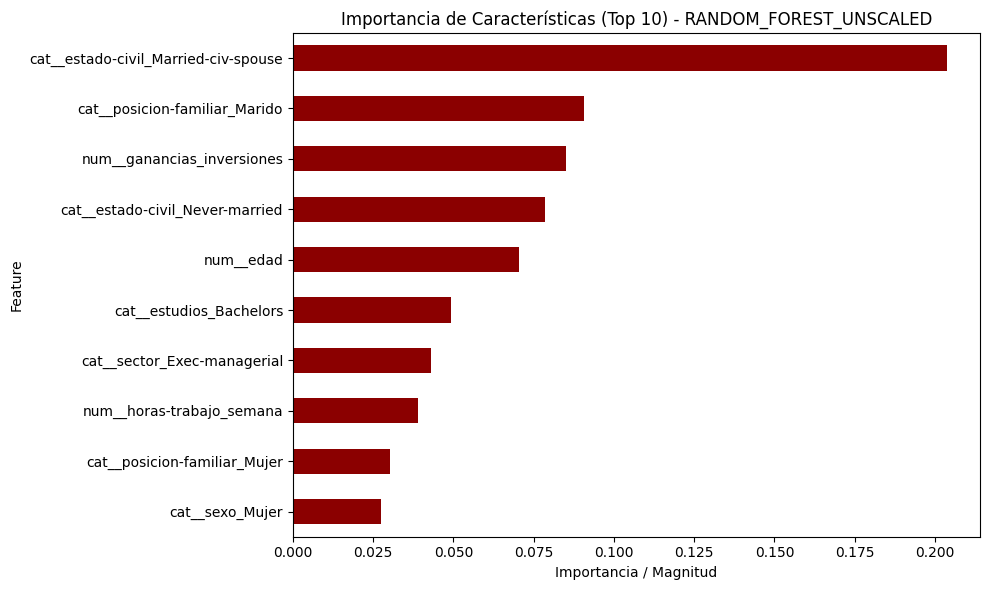

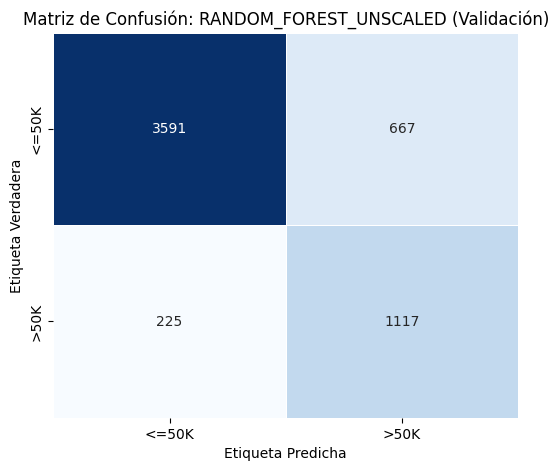

 Guardado: test_labels.csv
   ID salario
0   1   <=50K
1   2   <=50K
2   3   <=50K
3   4    >50K
4   5   <=50K
 Guardado: best_model.pkl y best_model_info.json
Guardado: model_search_results.csv


In [ ]:
# Elegir mejor modelo, refit en TRAIN+VALIDACIÓN, guardar mejor modelo y test_labels.csv 

# Elegir el mejor por F1 en VALIDACIÓN
assert "valid_f1" in results_df.columns, "results_df debe tener columna 'valid_f1'."
best_row = results_df.loc[results_df["valid_f1"].idxmax()]
best_key = best_row["model"]
best_params = best_row["best_params"]
best_dataset_name = best_row["dataset"] # nombre del dataset ganador

if isinstance(best_params, str):
    try:
        best_params = ast.literal_eval(best_params)
    except Exception:
        pass  # si ya es dict

print(" Mejor configuración (VALID) ")
print("model:", best_key)
print("dataset:", best_dataset_name)
print("best_params:", best_params)

# Selección de los datos correctos
if 'std' in best_dataset_name:
    dataset_key = 'STD'
elif 'minmax' in best_dataset_name:
    dataset_key = 'MINMAX'
else:
    dataset_key = 'LR_UNSCALED'

ds_best = DATASETS[dataset_key]

X_train_best = ds_best["X_train"]
y_train_best = ds_best["y_train"]
X_valid_best = ds_best["X_valid"]
y_valid_best = ds_best["y_valid"]
X_kaggle_best = ds_best["X_kaggle"]
ids_kaggle_best = ds_best["ids_kaggle"]

# Reentrenar en TRAIN+VALID
X_all = pd.concat([X_train_best, X_valid_best], axis=0)
y_all = np.concatenate([y_train_best, y_valid_best], axis=0)
print(f"Refiteando en X_all con shape: {X_all.shape}")

best_estimator = best_estimators[best_key]
best_estimator_all = clone(best_estimator)

# Asegurar hiperparámetros por si acaso
if isinstance(best_params, dict) and best_params:
    best_estimator_all.set_params(**best_params)

best_estimator_all.fit(X_all, y_all)

# Matriz de confusión final (sobre VALID)
y_valid_pred = best_estimator_all.predict(X_valid_best)
cm_final = confusion_matrix(y_valid_best, y_valid_pred)

# Importancias/top features
plot_feature_importance_final(
    estimator=best_estimator_all,
    feature_names=X_train_best.columns.tolist(),
    n_top=10,
    model_name=best_key.upper()
)

# Matriz de confusión
plot_confusion_matrix(
    cm=cm_final,
    class_names=label_classes,
    title=f'Matriz de Confusión: {best_key.upper()} (Validación)'
)

# Predicción TEST externo y guardado
y_kaggle_enc = best_estimator_all.predict(X_kaggle_best)
idx_to_label = {i: cls for i, cls in enumerate(label_classes)}
y_kaggle_lab = pd.Series(y_kaggle_enc).map(idx_to_label).values

submission = pd.DataFrame({"ID": ids_kaggle_best, "salario": y_kaggle_lab})
submission.to_csv("test_labels.csv", index=False)
print(" Guardado: test_labels.csv")
print(submission.head())

# Guardar el mejor modelo y metadatos
joblib.dump(best_estimator_all, "best_model.pkl")

# Convertir best_params a string si contiene objetos no serializables
final_best_params = best_params if isinstance(best_params, dict) else ast.literal_eval(best_params)

# Serializar el diccionario, asegurando que los parámetros sean cadenas
json_params = {}
for k, v in final_best_params.items():
    json_params[k] = str(v)

with open("best_model_info.json", "w") as f:
    json.dump({
        "model": best_key,
        "best_params": json_params,
        "valid_f1": float(best_row["valid_f1"]),
        "valid_accuracy": float(best_row["valid_accuracy"]),
        "cv_f1": float(best_row.get("cv_f1", np.nan)),
        "cv_accuracy": float(best_row.get("cv_accuracy", np.nan)),
        "feature_set": best_dataset_name
    }, f, indent=2)
print(" Guardado: best_model.pkl y best_model_info.json")

# Guardar ranking completo
results_df.to_csv("model_search_results.csv", index=False)
print("Guardado: model_search_results.csv")